In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import math

sys.path.append('home/diego/repos@uibcdf/topomt/sandbox/geometry_playground/core')
from core.permeability import check_face_permeability
from core.apollonius import solve_apollonius_js_port # Assuming this is the main apollonius solver
from core.utils import is_point_in_triangle_2d

def project_to_2d(p1, p2, p3, epsilon=1e-6):
    """Projects 3D atom centers to a 2D plane."""
    orig_p1 = p1
    v12_3d = p2 - orig_p1
    v13_3d = p3 - orig_p1
    
    norm_v12 = np.linalg.norm(v12_3d)
    if norm_v12 < epsilon: raise ValueError("Degenerate points for projection.")
    u_vec = v12_3d / norm_v12
    
    v_perp_to_u = v13_3d - np.dot(v13_3d, u_vec) * u_vec
    norm_v_perp = np.linalg.norm(v_perp_to_u)
    if norm_v_perp < epsilon: raise ValueError("Degenerate points for projection.")
    v_vec = v_perp_to_u / norm_v_perp
    
    c1_2d = np.array([0.0, 0.0])
    c2_2d = np.array([norm_v12, 0.0])
    c3_2d = np.array([np.dot(v13_3d, u_vec), np.dot(v13_3d, v_vec)])
    return c1_2d, c2_2d, c3_2d

def get_best_gate_candidate_for_vis(p1_3d, r1, p2_3d, r2, p3_3d, r3, epsilon=1e-6):
    """
    Replicates check_face_permeability logic to return best candidate for visualization.
    Returns (radius, center, type) of the winning candidate.
    """
    max_r_gate_candidates_with_info = []
    
    c1_2d, c2_2d, c3_2d = project_to_2d(p1_3d, p2_3d, p3_3d, epsilon)
    
    # --- Apollonius Solutions ---
    sol = solve_apollonius_js_port(c1_2d, r1, c2_2d, r2, c3_2d, r3, epsilon)
    if sol:
        r_sol, center_sol = sol
        if r_sol > epsilon and is_point_in_triangle_2d(center_sol, c1_2d, c2_2d, c3_2d, epsilon=epsilon, strict_interior=False):
            max_r_gate_candidates_with_info.append((r_sol, center_sol, 'Apollonius'))
            
    # --- Edge-limited Solutions ---
    atom_data_2d = [(c1_2d, r1), (c2_2d, r2), (c3_2d, r3)]
    tri_points_2d = [c1_2d, c2_2d, c3_2d]
    
    for i in range(3):
        for j in range(i + 1, 3):
            cA_2d, rA = atom_data_2d[i]
            cB_2d, rB = atom_data_2d[j]
            cC_2d, rC = atom_data_2d[3 - i - j] 
            
            dist_AB = np.linalg.norm(cA_2d - cB_2d)
            r_cand = max(0.0, (dist_AB - rA - rB) / 2.0)
            
            if r_cand > epsilon:
                vec_AB = (cB_2d - cA_2d) / dist_AB
                center = cA_2d + (rA + r_cand) * vec_AB
                
                if np.linalg.norm(center - cC_2d) >= (rC + r_cand - epsilon) and \
                   is_point_in_triangle_2d(center, *tri_points_2d, epsilon=epsilon, strict_interior=False):
                    max_r_gate_candidates_with_info.append((r_cand, center, 'Edge'))
    
    # --- Incircle Heuristic ---
    # This heuristic is kept for visualization as it often represents a clear 'inner hole'
    # even if Apollonius finds a larger, more encompassing solution.
    if abs(r1 - r2) < epsilon and abs(r2 - r3) < epsilon: # Only if radii are approximately equal
        s = (np.linalg.norm(c1_2d - c2_2d) + np.linalg.norm(c2_2d - c3_2d) + np.linalg.norm(c3_2d - c1_2d)) / 2.0
        area = 0.5 * abs(c1_2d[0]*(c2_2d[1]-c3_2d[1]) + c2_2d[0]*(c3_2d[1]-c1_2d[1]) + c3_2d[0]*(c1_2d[1]-c2_2d[1]))
        if s > epsilon:
            incircle_radius_geometric = area / s
            r_incircle_candidate = max(0.0, incircle_radius_geometric - r1) # Subtract common radius
            if r_incircle_candidate > epsilon:
                 a_len = np.linalg.norm(c2_2d-c3_2d)
                 b_len = np.linalg.norm(c1_2d-c3_2d)
                 c_len = np.linalg.norm(c1_2d-c2_2d)
                 perimeter = a_len+b_len+c_len
                 if perimeter > epsilon:
                    incenter_2d = (a_len*c1_2d + b_len*c2_2d + c_len*c3_2d)/perimeter
                    max_r_gate_candidates_with_info.append((r_incircle_candidate, incenter_2d, 'Incircle'))
                    
    if not max_r_gate_candidates_with_info:
        # Default if no valid gate found, use triangle centroid
        return 0.0, np.array([np.mean([c1_2d[0],c2_2d[0],c3_2d[0]]), np.mean([c1_2d[1],c2_2d[1],c3_2d[1]])]), 'None'
        
    # Select the maximum valid radius found (and its center)
    best_candidate = max(max_r_gate_candidates_with_info, key=lambda x: x[0])
    return best_candidate


def plot_case(p1_3d, r1, p2_3d, r2, p3_3d, r3, probe_radius, title):
    passable, r_gate_analytic = check_face_permeability(p1_3d, p2_3d, p3_3d, r1, r2, r3, probe_radius)
    
    c1_2d, c2_2d, c3_2d = project_to_2d(p1_3d, p2_3d, p3_3d)
    
    r_vis, center_vis, type_vis = get_best_gate_candidate_for_vis(p1_3d, r1, p2_3d, r2, p3_3d, r3)
    
    fig, ax = plt.subplots(figsize=(8,8))
    
    # Draw Atoms
    ax.add_patch(plt.Circle(c1_2d, r1, color='green', alpha=0.3, label=f'Atom 1 (r={r1})'))
    ax.add_patch(plt.Circle(c2_2d, r2, color='green', alpha=0.3, label=f'Atom 2 (r={r2})'))
    ax.add_patch(plt.Circle(c3_2d, r3, color='green', alpha=0.3, label=f'Atom 3 (r={r3})'))
    
    # Draw Triangle
    triangle = plt.Polygon([c1_2d, c2_2d, c3_2d], fill=None, edgecolor='black', linestyle='--', alpha=0.5, label='Face Outline')
    ax.add_patch(triangle)
    
    # Draw Gate
    if r_vis > 0:
        ax.add_patch(plt.Circle(center_vis, r_vis, fill=False, edgecolor='red', linewidth=2, linestyle='--', label=f'Gate (R={r_vis:.3f}, {type_vis})'))
        ax.plot(center_vis[0], center_vis[1], 'rx', markersize=8, label='Gate Center')
        
    # Draw Probe (hypothetical)
    if passable:
        probe_circle = plt.Circle(center_vis if r_vis>0 else (c1_2d+c2_2d+c3_2d)/3, probe_radius, color='blue', alpha=0.2, label=f'Probe (R={probe_radius})')
        ax.add_patch(probe_circle)
    else:
        # Draw probe but mark it as blocked
        probe_circle = plt.Circle(center_vis if r_vis>0 else (c1_2d+c2_2d+c3_2d)/3, probe_radius, color='gray', alpha=0.1, label=f'Probe (R={probe_radius}) Blocked')
        ax.add_patch(probe_circle)
        # Draw a cross over the probe if blocked
        if r_vis > 0:
            ax.plot([center_vis[0]-probe_radius, center_vis[0]+probe_radius], [center_vis[1]-probe_radius, center_vis[1]+probe_radius], 'x', color='blue', markersize=10, mew=2)
            ax.plot([center_vis[0]-probe_radius, center_vis[0]+probe_radius], [center_vis[1]+probe_radius, center_vis[1]-probe_radius], 'x', color='blue', markersize=10, mew=2)
        else: # Default center if no gate found
            cent_x, cent_y = (c1_2d+c2_2d+c3_2d)/3
            ax.plot([cent_x-probe_radius, cent_x+probe_radius], [cent_y-probe_radius, cent_y+probe_radius], 'x', color='blue', markersize=10, mew=2)
            ax.plot([cent_x-probe_radius, cent_x+probe_radius], [cent_y+probe_radius, cent_y-probe_radius], 'x', color='blue', markersize=10, mew=2)
        

    # Set limits
    all_coords = np.array([c1_2d, c2_2d, c3_2d, center_vis])
    min_x, max_x = np.min(all_coords[:,0]) - max(r1,r2,r3,r_vis,probe_radius,1)-1, np.max(all_coords[:,0]) + max(r1,r2,r3,r_vis,probe_radius,1)+1
    min_y, max_y = np.min(all_coords[:,1]) - max(r1,r2,r3,r_vis,probe_radius,1)-1, np.max(all_coords[:,1]) + max(r1,r2,r3,r_vis,probe_radius,1)+1
    ax.set_xlim(min_x, max_x)
    ax.set_ylim(min_y, max_y)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f"{title}\nPermeable: {passable} (Gate R={r_gate_analytic:.3f} vs Probe R={probe_radius})")
    ax.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


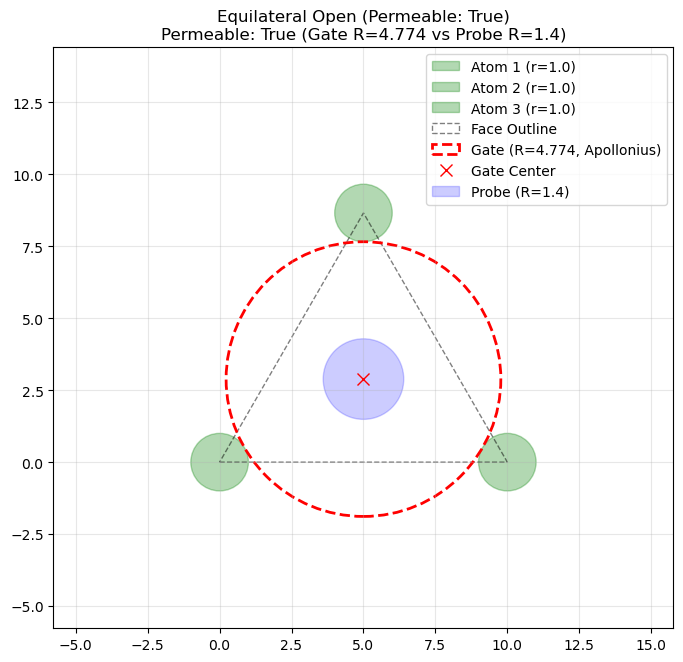

In [7]:
    
    # Test 1: Equilateral Open (Analytic: 4.7735) -> Permeable: True
    p1 = np.array([0, 0, 0])
    p2 = np.array([10, 0, 0])
    p3 = np.array([5, 8.66025404, 0]) # sqrt(75) = 8.66
    r_atom = 1.0
    probe_r = 1.4
    plot_case(p1, r_atom, p2, r_atom, p3, r_atom, probe_r, "Equilateral Open (Permeable: True)")


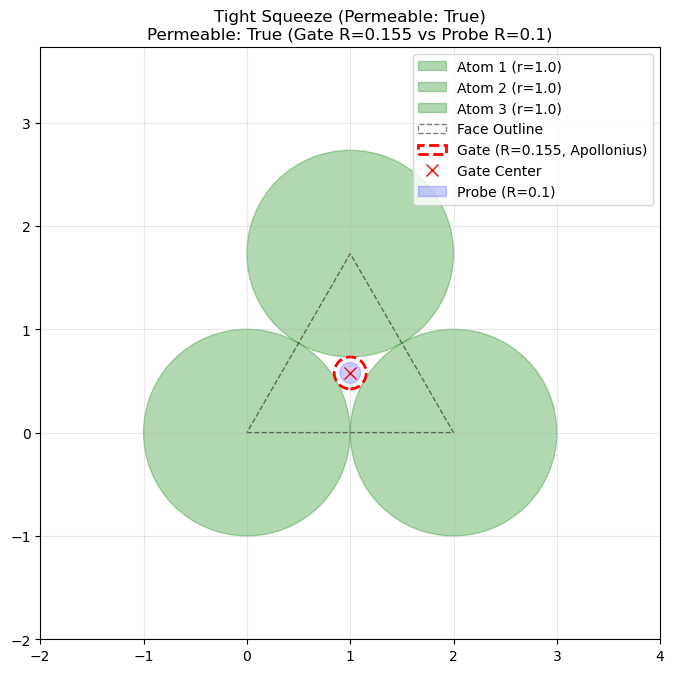

In [8]:

    # Test 2: Tight Squeeze (Analytic: 0.1547) -> Permeable: True
    p1 = np.array([0, 0, 0])
    p2 = np.array([2, 0, 0])
    p3 = np.array([1, np.sqrt(3), 0])
    r_atom = 1.0
    probe_r = 0.1
    plot_case(p1, r_atom, p2, r_atom, p3, r_atom, probe_r, "Tight Squeeze (Permeable: True)")


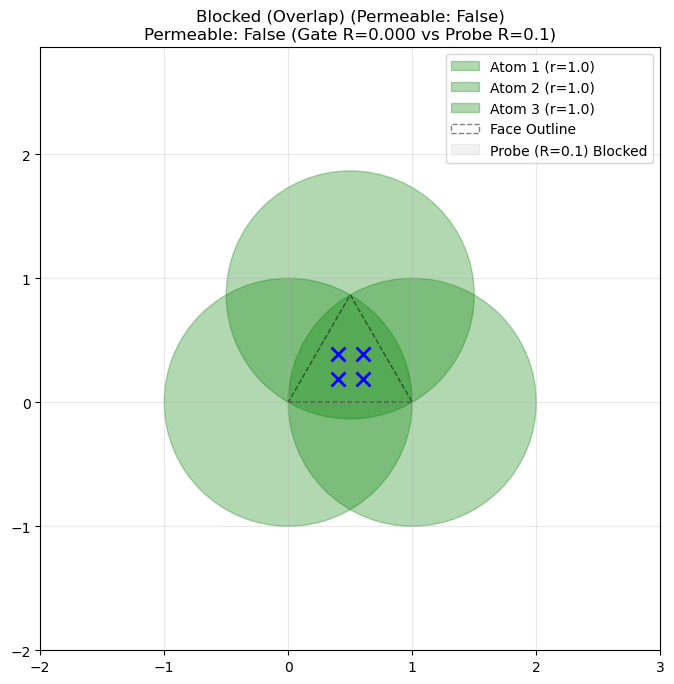

In [9]:

    # Test 3: Overlap Blocked (Analytic: 0.0) -> Permeable: False
    p1 = np.array([0, 0, 0])
    p2 = np.array([1, 0, 0])
    p3 = np.array([0.5, 0.866, 0])
    r_atom = 1.0 
    probe_r = 0.1
    plot_case(p1, r_atom, p2, r_atom, p3, r_atom, probe_r, "Blocked (Overlap) (Permeable: False)")


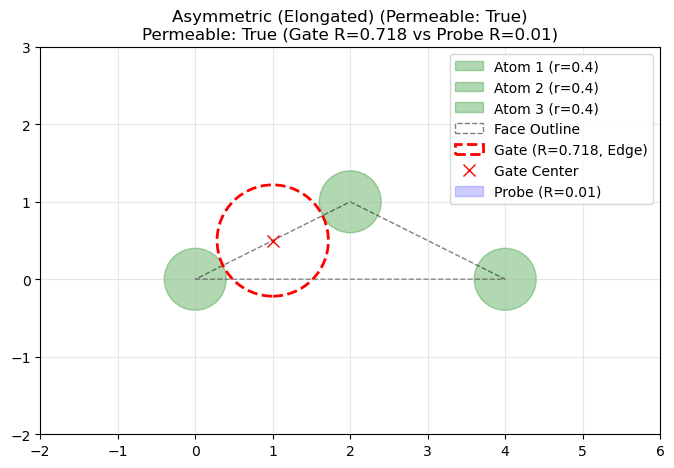

In [10]:

    # Test 4: Asymmetric Elongated (Analytic: ~0.718) -> Permeable: True (for small probe)
    p1 = np.array([0, 0, 0])
    p2 = np.array([4, 0, 0])
    p3 = np.array([2, 1, 0])
    r_atom = 0.4
    probe_r = 0.01
    plot_case(p1, r_atom, p2, r_atom, p3, r_atom, probe_r, "Asymmetric (Elongated) (Permeable: True)")